# 📘 Linear Regression — End-to-End Hands-on Assignment
**NextGen Alpha | ML Assignment**

---
### 🏠 Scenario: Predicting House Sale Prices

We simulate a realistic housing dataset that includes:
- Numerical features: area (sq ft), age, distance to city, number of rooms
- Categorical feature: locality type (Urban / Suburban / Rural)
- Missing values (intentionally introduced)
- Outliers (a few unusually priced houses)

**Goal:** Build a Linear Regression model to predict `sale_price`.

---
## 📦 Step 0 — Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid', palette='muted')

---
## 🏗️ Step 1 — Data Creation

We generate a synthetic dataset with **500 rows** using a realistic formula:

```
sale_price ≈ 50*area + 3000*rooms - 200*age - 1000*dist_to_city + locality_effect + noise
```

We then:
- Add a **correlated feature** (`area_sqm`) to demonstrate multicollinearity
- Introduce **~10% missing values** in `age` and `dist_to_city`
- Inject **5 outliers** with extreme prices

In [2]:
n = 500

# --- Core numerical features ---
area_sqft    = np.random.randint(500, 3500, n)
num_rooms    = np.random.randint(1, 7, n)
house_age    = np.random.randint(1, 40, n).astype(float)
dist_to_city = np.random.uniform(1, 50, n)

# --- Correlated feature (area in sq metres — nearly same info as sqft) ---
area_sqm = area_sqft * 0.0929 + np.random.normal(0, 0.5, n)

# --- Categorical feature ---
locality = np.random.choice(['Urban', 'Suburban', 'Rural'], n, p=[0.4, 0.35, 0.25])
locality_map = {'Urban': 30000, 'Suburban': 15000, 'Rural': 0}
locality_effect = np.array([locality_map[l] for l in locality])

# --- Target variable with noise ---
noise = np.random.normal(0, 8000, n)
sale_price = (50 * area_sqft
              + 3000 * num_rooms
              - 200  * house_age
              - 1000 * dist_to_city
              + locality_effect
              + noise)
sale_price = np.clip(sale_price, 20000, None)

# --- Build DataFrame ---
df = pd.DataFrame({
    'area_sqft'   : area_sqft,
    'area_sqm'    : area_sqm.round(2),
    'num_rooms'   : num_rooms,
    'house_age'   : house_age,
    'dist_to_city': dist_to_city.round(2),
    'locality'    : locality,
    'sale_price'  : sale_price.round(2)
})

# --- Introduce ~10% missing values ---
missing_idx_age  = np.random.choice(n, size=int(0.10 * n), replace=False)
missing_idx_dist = np.random.choice(n, size=int(0.08 * n), replace=False)
df.loc[missing_idx_age,  'house_age']    = np.nan
df.loc[missing_idx_dist, 'dist_to_city'] = np.nan

# --- Inject 5 price outliers ---
outlier_idx = np.random.choice(n, size=5, replace=False)
df.loc[outlier_idx[:3], 'sale_price'] *= 5
df.loc[outlier_idx[3:], 'sale_price'] *= 0.1

df.head()

,area_sqft,area_sqm,num_rooms,house_age,dist_to_city,locality,sale_price
0,1360,126.96,6,11.0,NaN,Suburban,81143.61
1,1794,167.47,5,30.0,19.83,Urban,108534.55
2,1630,150.66,4,31.0,34.30,Suburban,84140.55
3,1595,148.31,2,24.0,11.69,Suburban,85986.09
4,2138,199.35,4,9.0,47.55,Rural,77980.80


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_sqft     500 non-null    int64  
 1   area_sqm      500 non-null    float64
 2   num_rooms     500 non-null    int64  
 3   house_age     450 non-null    float64
 4   dist_to_city  460 non-null    float64
 5   locality      500 non-null    str    
 6   sale_price    500 non-null    float64
dtypes: float64(4), int64(2), str(1)
memory usage: 27.5 KB


In [4]:
df.describe().round(2)

,area_sqft,area_sqm,num_rooms,house_age,dist_to_city,sale_price
count,500.00,500.00,500.00,450.00,460.00,500.00
mean,2022.42,187.88,3.44,20.40,25.88,101634.47
std,845.05,78.50,1.71,11.46,14.35,56462.41
min,501.00,45.67,1.00,1.00,1.24,2000.00
25%,1315.00,121.65,2.00,10.00,12.60,64824.15
50%,2009.50,186.36,3.00,21.00,26.60,96848.55
75%,2753.50,256.24,5.00,30.00,38.18,135865.68
max,3499.00,324.95,6.00,39.00,49.86,731722.45


---
## 🔍 Step 2 — Exploratory Data Analysis (EDA)

### 2a. Missing Value Analysis

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})

,Missing Count,Missing %
area_sqft,0,0.0
area_sqm,0,0.0
num_rooms,0,0.0
house_age,50,10.0
dist_to_city,40,8.0
locality,0,0.0
sale_price,0,0.0


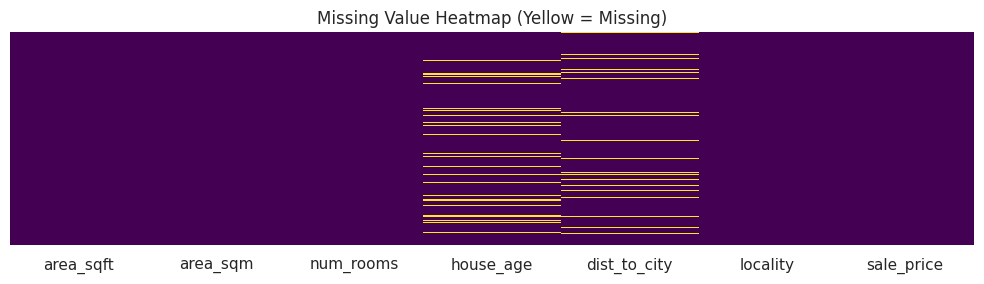

In [6]:
plt.figure(figsize=(10, 3))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Value Heatmap (Yellow = Missing)')
plt.tight_layout()
plt.show()

### 2b. Distribution of Numerical Features

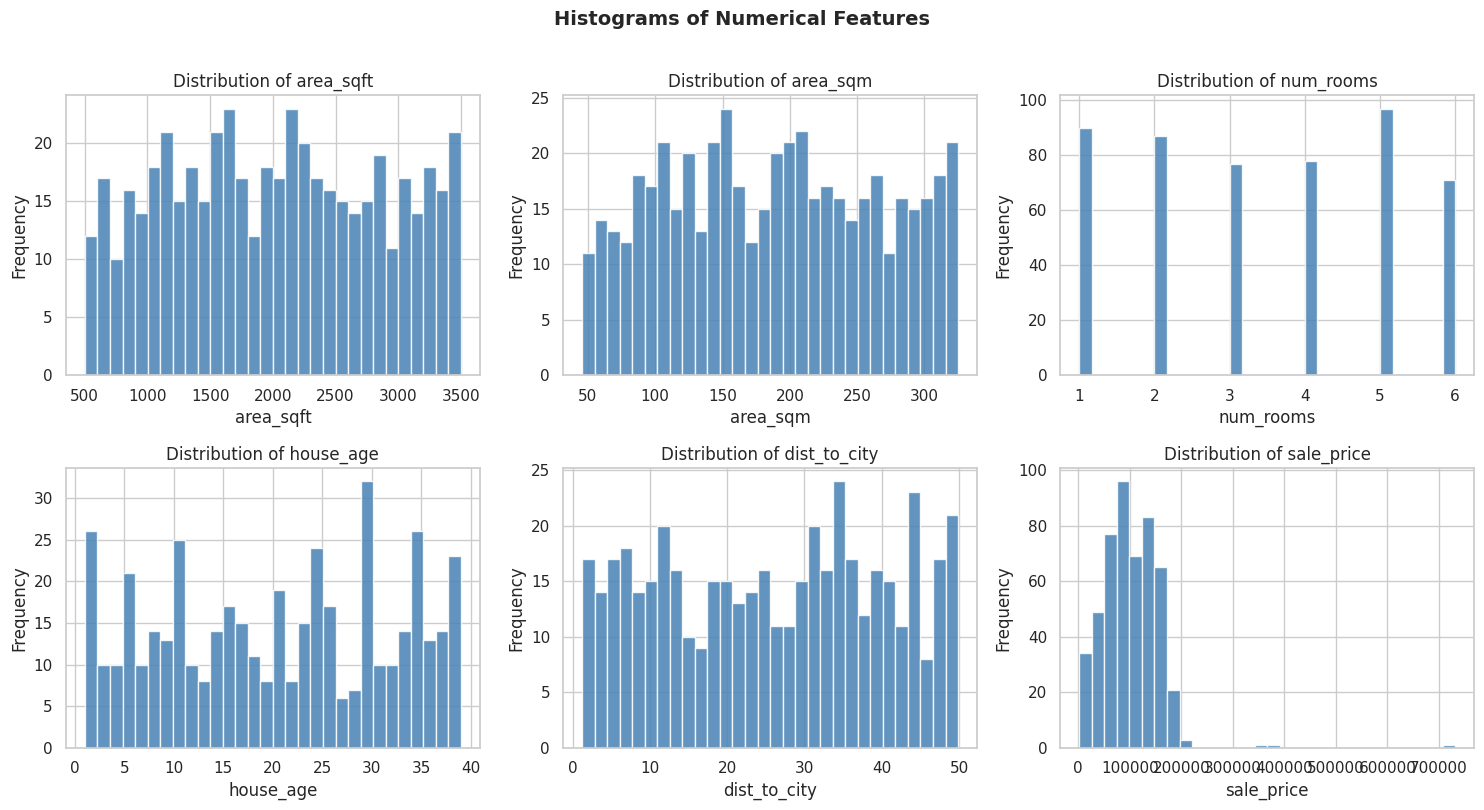

In [7]:
num_cols = ['area_sqft', 'area_sqm', 'num_rooms', 'house_age', 'dist_to_city', 'sale_price']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), num_cols):
    ax.hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
plt.suptitle('Histograms of Numerical Features', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 2c. Outlier Detection via Box Plots

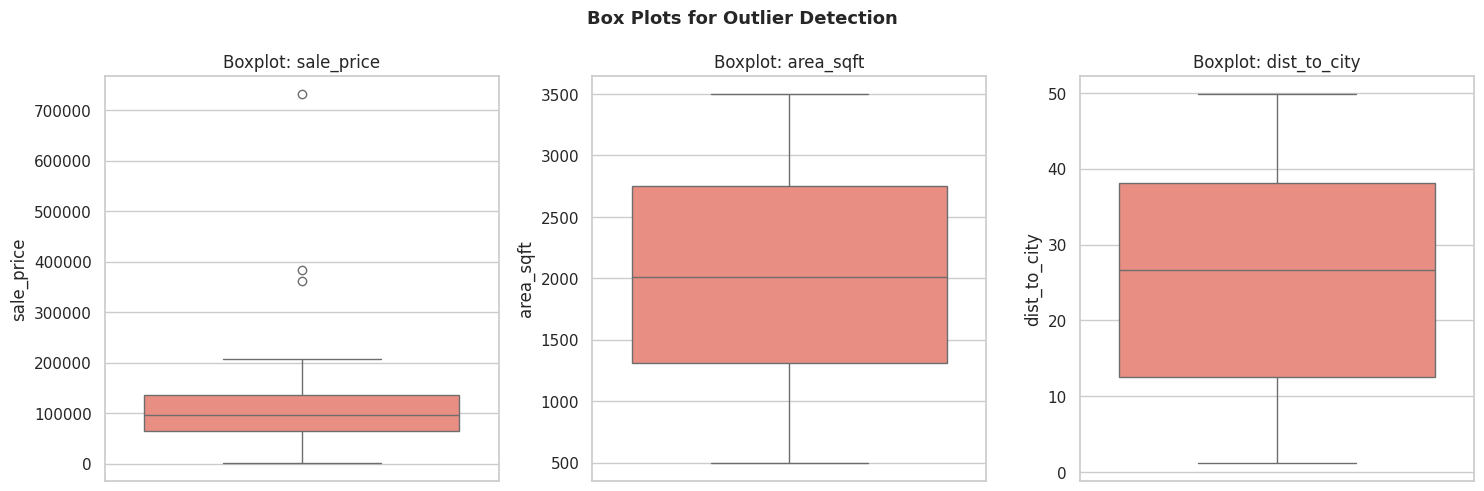

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, ['sale_price', 'area_sqft', 'dist_to_city']):
    sns.boxplot(y=df[col], ax=ax, color='salmon')
    ax.set_title(f'Boxplot: {col}')
plt.suptitle('Box Plots for Outlier Detection', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 2d. Categorical Feature Analysis

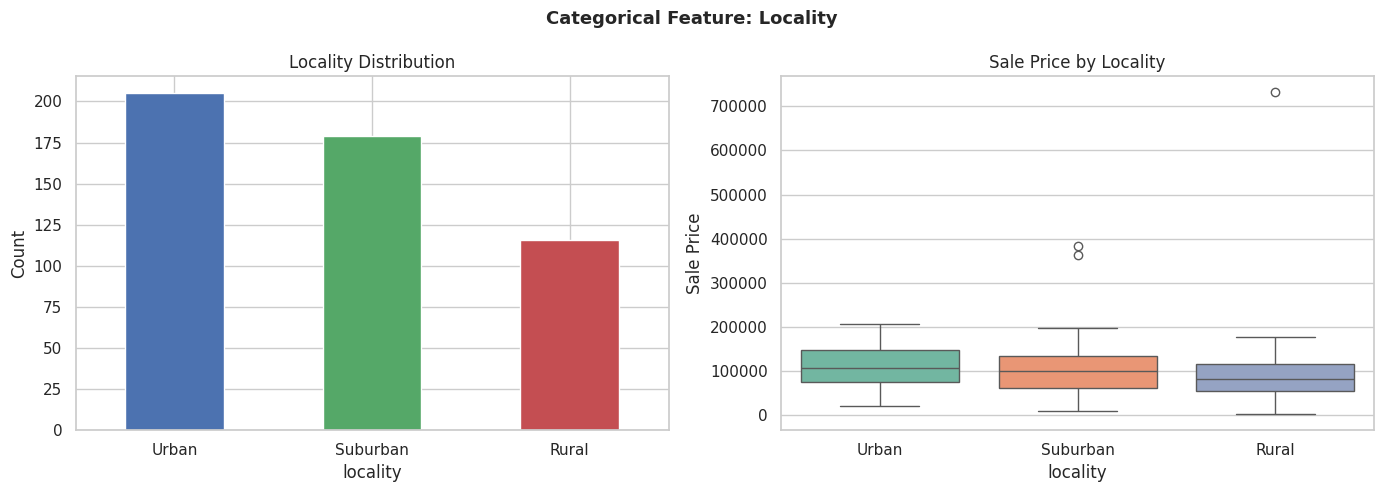

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['locality'].value_counts().plot(kind='bar', ax=axes[0],
                                   color=['#4C72B0','#55A868','#C44E52'],
                                   edgecolor='white', rot=0)
axes[0].set_title('Locality Distribution')
axes[0].set_ylabel('Count')

sns.boxplot(x='locality', y='sale_price', data=df, ax=axes[1], palette='Set2',
            order=['Urban','Suburban','Rural'])
axes[1].set_title('Sale Price by Locality')
axes[1].set_ylabel('Sale Price')

plt.suptitle('Categorical Feature: Locality', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 2e. Correlation Analysis — Detecting Multicollinearity

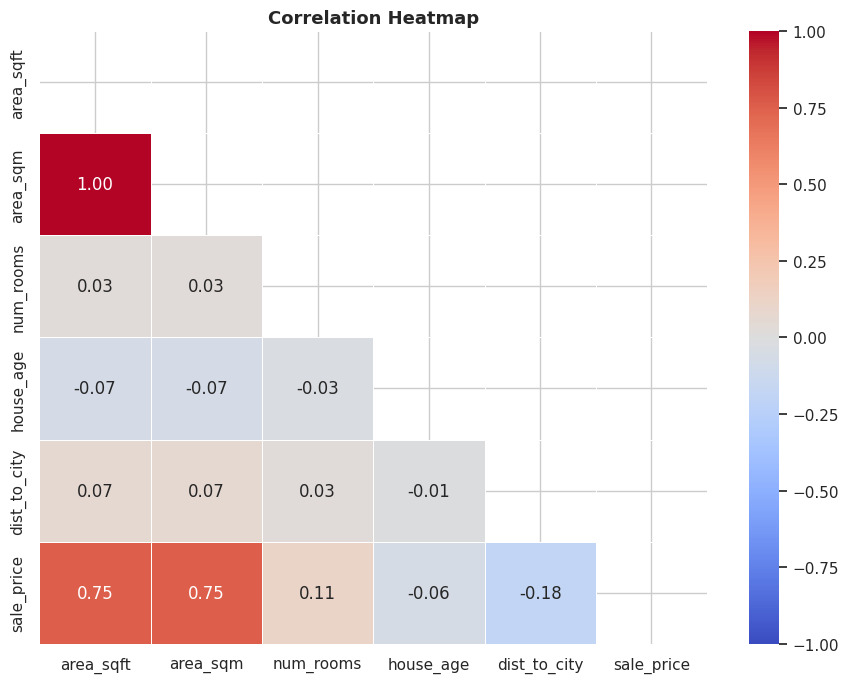

In [10]:
corr = df[num_cols].corr().round(2)

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', mask=mask,
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 2f. Scatter Plots: Features vs Target

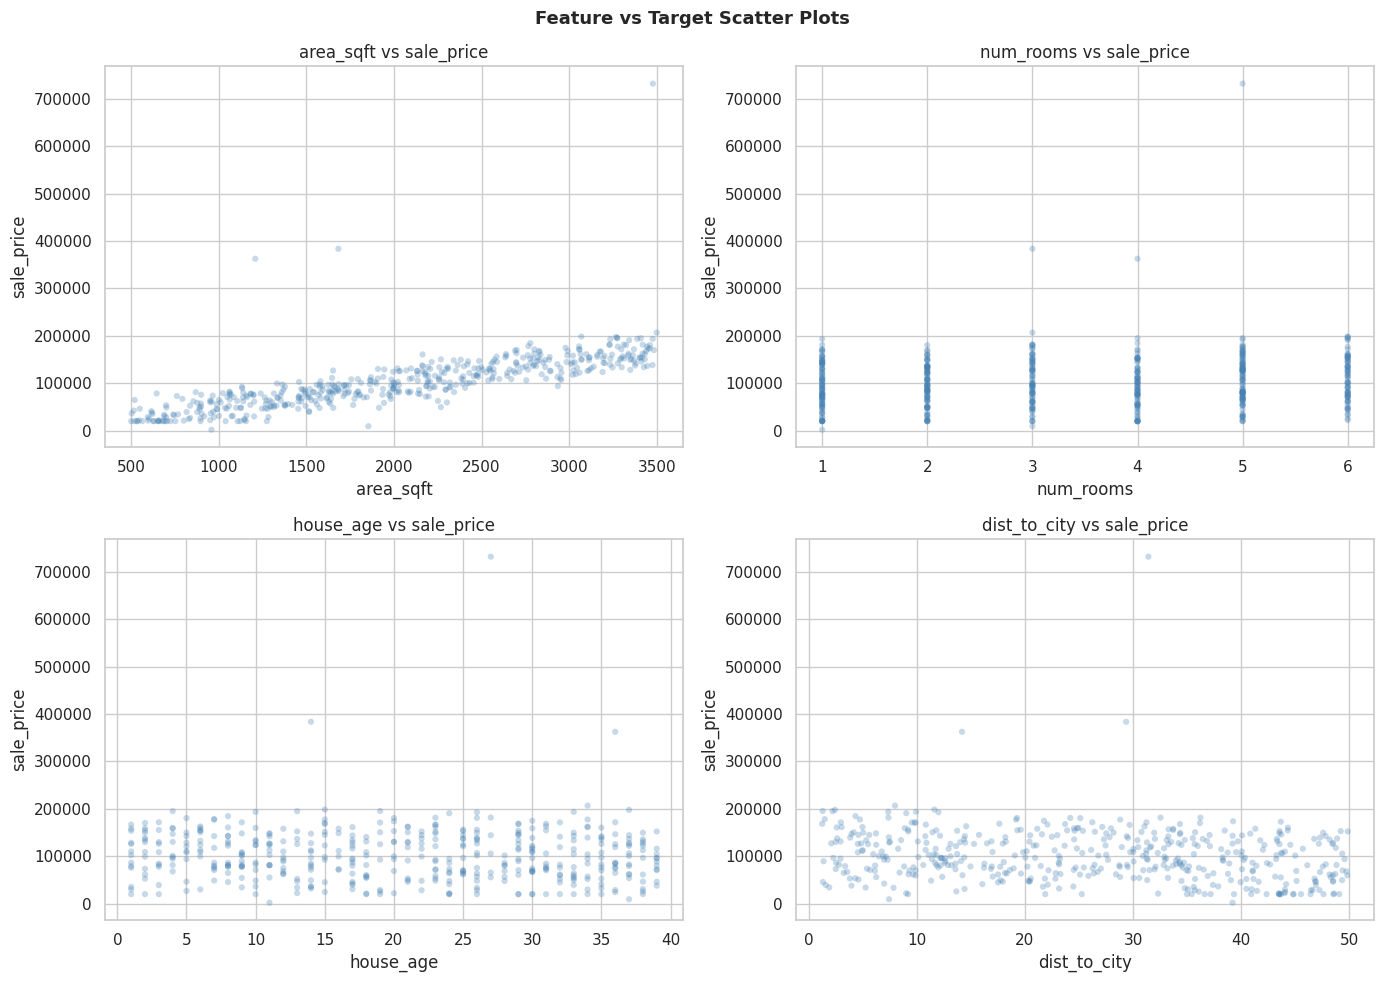

In [11]:
features_to_plot = ['area_sqft', 'num_rooms', 'house_age', 'dist_to_city']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, feat in zip(axes.flatten(), features_to_plot):
    ax.scatter(df[feat], df['sale_price'], alpha=0.3, color='steelblue', edgecolors='none', s=20)
    ax.set_xlabel(feat)
    ax.set_ylabel('sale_price')
    ax.set_title(f'{feat} vs sale_price')

plt.suptitle('Feature vs Target Scatter Plots', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🛠️ Step 3 — Data Preprocessing

### 3a. Drop Highly Correlated Feature (Fix Multicollinearity)

In [12]:
df_clean = df.copy()
df_clean.drop(columns=['area_sqm'], inplace=True)

### 3b. Handle Missing Values

In [13]:
# Impute with MEDIAN — robust to skew and outliers
df_clean['house_age']    = df_clean['house_age'].fillna(df_clean['house_age'].median())
df_clean['dist_to_city'] = df_clean['dist_to_city'].fillna(df_clean['dist_to_city'].median())

df_clean.isnull().sum()

area_sqft       0
num_rooms       0
house_age       0
dist_to_city    0
locality        0
sale_price      0
dtype: int64

### 3c. Treat Outliers using IQR Method

In [14]:
Q1 = df_clean['sale_price'].quantile(0.25)
Q3 = df_clean['sale_price'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outlier_mask = (df_clean['sale_price'] < lower) | (df_clean['sale_price'] > upper)
df_clean = df_clean[~outlier_mask].reset_index(drop=True)
df_clean.shape

(497, 6)

### 3d. Encode Categorical Variable

In [15]:
# One-Hot Encoding; drop_first=True avoids the Dummy Variable Trap
df_clean = pd.get_dummies(df_clean, columns=['locality'], drop_first=True)
df_clean.head(3)

,area_sqft,num_rooms,house_age,dist_to_city,sale_price,locality_Suburban,locality_Urban
0,1360,6,11.0,26.60,81143.61,True,False
1,1794,5,30.0,19.83,108534.55,False,True
2,1630,4,31.0,34.30,84140.55,True,False


### 3e. Train-Test Split

In [ ]:
y=B0+x1B1+x2B2+x3B3

In [16]:
X = df_clean.drop(columns=['sale_price'])
y = df_clean['sale_price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((397, 6), (100, 6))

---
## 🤖 Step 4 — Model Building

### 4a. Linear Regression from Scratch (Normal Equation)

$$\hat{\beta} = (X^TX)^{-1} X^T y$$

In [17]:
# Add bias column
X_train_b = np.c_[np.ones(len(X_train)), X_train.values.astype(float)]
X_test_b  = np.c_[np.ones(len(X_test)),  X_test.values.astype(float)]
y_train_np = y_train.values.astype(float)

# Normal Equation
beta = np.linalg.inv(X_train_b.T @ X_train_b) @ X_train_b.T @ y_train_np

y_pred_scratch = X_test_b @ beta

# Coefficients table
pd.DataFrame({'Feature': ['intercept'] + list(X.columns), 'Coefficient (Scratch)': beta})

,Feature,Coefficient (Scratch)
0,intercept,164.029646
1,area_sqft,49.924467
2,num_rooms,2849.329868
3,house_age,-198.034945
4,dist_to_city,-942.089714
5,locality_Suburban,13563.965854
6,locality_Urban,29035.854501


### 4b. Linear Regression using Scikit-Learn

In [18]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_sklearn = lr.predict(X_test)

# Coefficients table
pd.DataFrame({'Feature': X.columns, 'Coefficient (sklearn)': lr.coef_})

,Feature,Coefficient (sklearn)
0,area_sqft,49.924467
1,num_rooms,2849.329868
2,house_age,-198.034945
3,dist_to_city,-942.089714
4,locality_Suburban,13563.965854
5,locality_Urban,29035.854501


---
## 📊 Step 5 — Model Evaluation

### 5a. Evaluation Metrics

In [19]:
def evaluate(y_true, y_pred, model_name='Model'):
    return pd.DataFrame([{
        'Model' : model_name,
        'MAE'   : mean_absolute_error(y_true, y_pred),
        'MSE'   : mean_squared_error(y_true, y_pred),
        'RMSE'  : np.sqrt(mean_squared_error(y_true, y_pred)),
        'R²'    : r2_score(y_true, y_pred)
    }]).round(4)

pd.concat([
    evaluate(y_test, y_pred_scratch,  'Normal Equation (Scratch)'),
    evaluate(y_test, y_pred_sklearn,  'Scikit-Learn')
], ignore_index=True)

,Model,MAE,MSE,RMSE,R²
0,Normal Equation (Scratch),6886.0004,7.738731e+07,8797.0058,0.9557
1,Scikit-Learn,6886.0004,7.738731e+07,8797.0058,0.9557


### 5b. Actual vs Predicted Plot

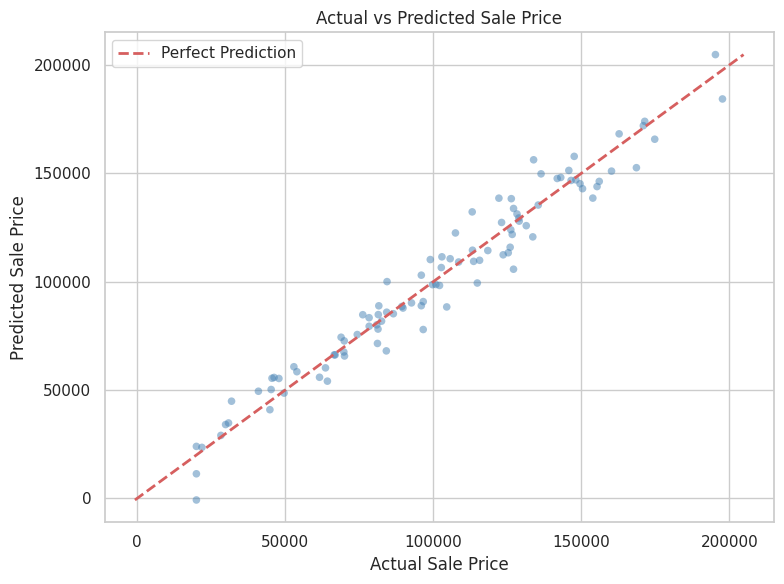

In [20]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_sklearn, alpha=0.5, color='steelblue', edgecolors='none', s=30)
min_val = min(y_test.min(), y_pred_sklearn.min())
max_val = max(y_test.max(), y_pred_sklearn.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Sale Price')
plt.ylabel('Predicted Sale Price')
plt.title('Actual vs Predicted Sale Price')
plt.legend()
plt.tight_layout()
plt.show()

### 5c. Residual Analysis

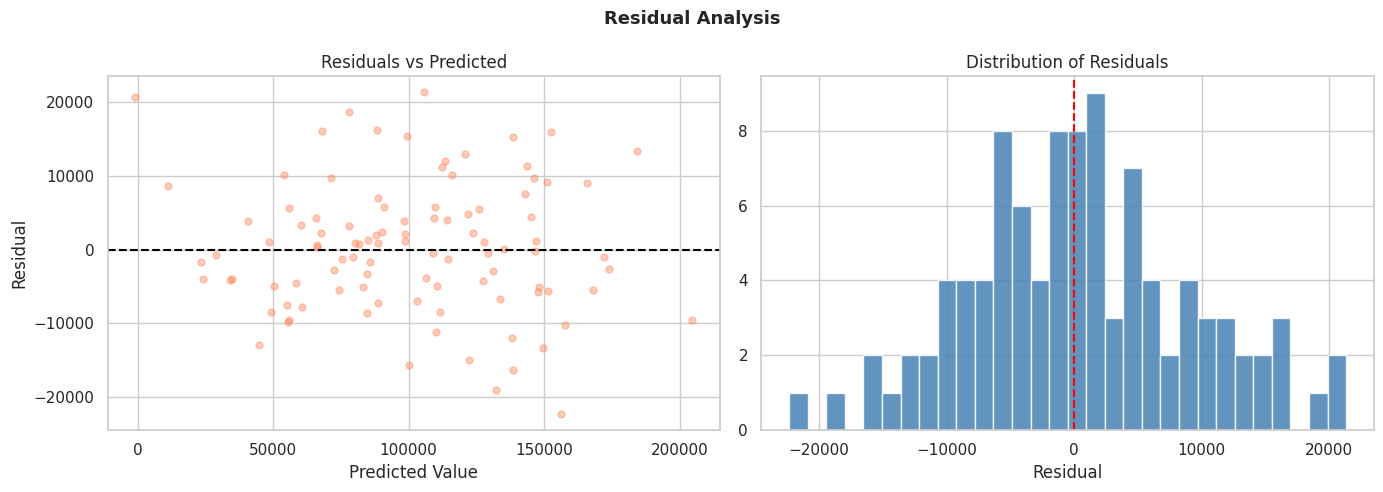

In [21]:
residuals = y_test.values - y_pred_sklearn

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_pred_sklearn, residuals, alpha=0.4, color='coral', s=25)
axes[0].axhline(0, color='black', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Predicted Value')
axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs Predicted')

axes[1].hist(residuals, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Residual')
axes[1].set_title('Distribution of Residuals')

plt.suptitle('Residual Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 5d. Coefficient Interpretation

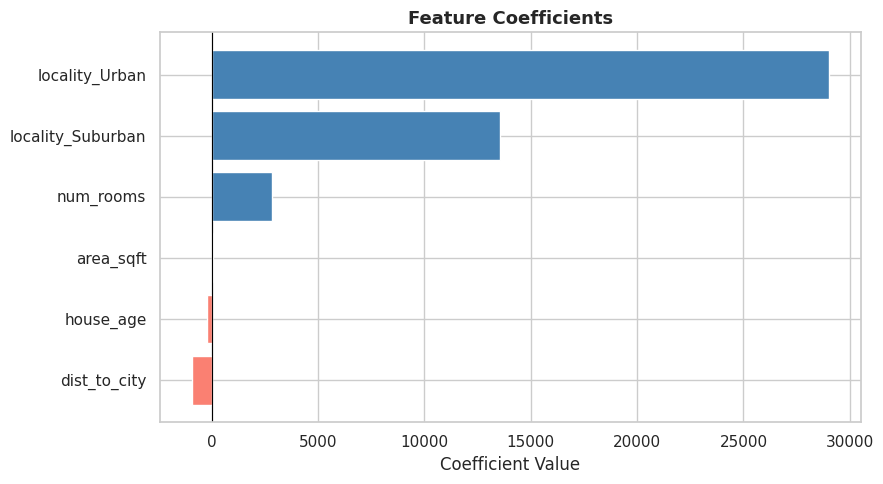

In [22]:
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': lr.coef_})
coef_df = coef_df.sort_values('Coefficient', ascending=True)

plt.figure(figsize=(9, 5))
colors = ['salmon' if c < 0 else 'steelblue' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Coefficients', fontsize=13, fontweight='bold')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

### 5e. Train vs Test R² — Checking for Overfitting

In [23]:
r2_train = r2_score(y_train, lr.predict(X_train))
r2_test  = r2_score(y_test,  y_pred_sklearn)

pd.DataFrame([{
    'R² Train' : round(r2_train, 4),
    'R² Test'  : round(r2_test, 4),
    'Difference': round(abs(r2_train - r2_test), 4)
}])

,R² Train,R² Test,Difference
0,0.9554,0.9557,0.0003


---
## 📝 Step 6 — Key Observations & Summary

| Step | Action | Reason |
|------|--------|--------|
| Data Creation | Synthetic housing data with formula-based target | Controlled ground truth for learning |
| EDA | Heatmap, histograms, scatter, box plots | Understand distributions, outliers, relationships |
| Multicollinearity | Dropped `area_sqm` (r ≈ 1.0 with `area_sqft`) | Redundant feature destabilises coefficients |
| Missing Values | Median imputation | Robust to skew and outliers |
| Outliers | IQR removal | Prevents extreme values distorting model fit |
| Encoding | One-Hot with `drop_first=True` | Nominal variable; avoids dummy variable trap |
| Model | Normal Equation + sklearn `LinearRegression` | Both give identical results, validates scratch impl |
| Evaluation | MAE, RMSE, R², residual plots | R² ≈ high; residuals centered at 0 → good fit |
| Overfitting check | Train vs Test R² gap | Small gap → model generalises well |

---
*End of Assignment — NextGen Alpha | Linear Regression*